In [12]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import importlib
import sys
from pathlib import Path
from sklearn.metrics import roc_auc_score

sys.path.append(str(Path().resolve().parent))
import importlib
import config
importlib.reload(config)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Using device: {config.DEVICE}")

PyTorch version: 2.11.0+cu128
CUDA available: True
Using device: cuda


In [13]:
# Load preprocessed splits
X_train = np.load(config.PROCESSED_DIR / "X_train.npy")
X_val   = np.load(config.PROCESSED_DIR / "X_val.npy")
X_test  = np.load(config.PROCESSED_DIR / "X_test.npy")
y_train = np.load(config.PROCESSED_DIR / "y_train.npy")
y_val   = np.load(config.PROCESSED_DIR / "y_val.npy")
y_test  = np.load(config.PROCESSED_DIR / "y_test.npy")

print(f"Train:      {X_train.shape} | Labels: {np.bincount(y_train)}")
print(f"Validation: {X_val.shape}   | Labels: {np.bincount(y_val)}")
print(f"Test:       {X_test.shape}  | Labels: {np.bincount(y_test)}")

Train:      (239277, 8) | Labels: [196606  42671]
Validation: (34183, 8)   | Labels: [28087  6096]
Test:       (68365, 8)  | Labels: [56173 12192]


In [14]:
class VariantDataset(Dataset):
    """
    PyTorch Dataset for ClinVar SNV variants.
    Takes numpy arrays and returns tensors for model training.
    """
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# Create datasets
train_dataset = VariantDataset(X_train, y_train)
val_dataset   = VariantDataset(X_val, y_val)
test_dataset  = VariantDataset(X_test, y_test)

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False
)

# Sanity check — peek at one batch
X_batch, y_batch = next(iter(train_loader))
print(f"Batch X shape: {X_batch.shape}")
print(f"Batch y shape: {y_batch.shape}")
print(f"Batch X dtype: {X_batch.dtype}")
print(f"Batch y dtype: {y_batch.dtype}")
print(f"\nExample input: {X_batch[0]}")
print(f"Example label: {y_batch[0]}")

Batch X shape: torch.Size([32, 8])
Batch y shape: torch.Size([32])
Batch X dtype: torch.float32
Batch y dtype: torch.float32

Example input: tensor([1., 0., 0., 0., 0., 0., 1., 0.])
Example label: 0.0


In [15]:
# Compute class weight for positive class (Pathogenic)
n_benign     = np.bincount(y_train)[0]
n_pathogenic = np.bincount(y_train)[1]
pos_weight   = torch.tensor([n_benign / n_pathogenic], dtype=torch.float32).to(config.DEVICE)

print(f"Benign (0):     {n_benign:,}")
print(f"Pathogenic (1): {n_pathogenic:,}")
print(f"pos_weight:     {pos_weight.item():.2f}")

Benign (0):     196,606
Pathogenic (1): 42,671
pos_weight:     4.61


In [16]:
class VariantMLP(nn.Module):
    """
    Baseline MLP for ClinVar SNV pathogenicity classification.
    
    Input: 8-dimensional one-hot encoded variant (ref + alt alleles)
    Output: single logit for binary classification (Pathogenic vs Benign)
    
    Architecture: 3 fully connected layers with ReLU activation and dropout.
    Deliberately simple — establishes baseline before CNN iteration.
    """
    def __init__(self, input_dim=8, hidden_dims=[64, 32], dropout=0.3):
        super(VariantMLP, self).__init__()

        self.network = nn.Sequential(
            # Layer 1
            nn.Linear(input_dim, hidden_dims[0]),
            nn.ReLU(),
            nn.Dropout(dropout),

            # Layer 2
            nn.Linear(hidden_dims[0], hidden_dims[1]),
            nn.ReLU(),
            nn.Dropout(dropout),

            # Output layer — single logit
            nn.Linear(hidden_dims[1], 1)
        )

    def forward(self, x):
        return self.network(x).squeeze(1)


# Instantiate model and move to device
model = VariantMLP().to(config.DEVICE)

# Loss function with class weighting
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Optimiser
optimiser = torch.optim.Adam(model.parameters(), lr=config.LEARNING_RATE)

# Print model summary
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Model device: {next(model.parameters()).device}")

VariantMLP(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total parameters: 2,689
Model device: cuda:0


In [17]:
from sklearn.metrics import roc_auc_score

def train_epoch(model, loader, criterion, optimiser, device):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimiser.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimiser.step()

        total_loss += loss.item()
        probs = torch.sigmoid(logits).detach().cpu().numpy()
        all_preds.extend(probs)
        all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader)
    auc = roc_auc_score(all_labels, all_preds)
    return avg_loss, auc


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            total_loss += loss.item()
            probs = torch.sigmoid(logits).detach().cpu().numpy()
            all_preds.extend(probs)
            all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader)
    auc = roc_auc_score(all_labels, all_preds)
    return avg_loss, auc


print("Training and evaluation functions defined.")

Training and evaluation functions defined.


In [18]:
# Training loop
NUM_EPOCHS = config.MAX_EPOCHS
best_val_auc = 0.0
best_model_state = None
history = {'train_loss': [], 'train_auc': [], 'val_loss': [], 'val_auc': []}

print(f"Training for {NUM_EPOCHS} epochs on {config.DEVICE}")
print(f"{'Epoch':>6} {'Train Loss':>12} {'Train AUC':>12} {'Val Loss':>10} {'Val AUC':>10}")
print("-" * 56)

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_auc = train_epoch(
        model, train_loader, criterion, optimiser, config.DEVICE
    )
    val_loss, val_auc = evaluate(
        model, val_loader, criterion, config.DEVICE
    )

    history['train_loss'].append(train_loss)
    history['train_auc'].append(train_auc)
    history['val_loss'].append(val_loss)
    history['val_auc'].append(val_auc)

    # Save best model
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_model_state = model.state_dict().copy()

    # Log every epoch
    print(f"{epoch:>6} {train_loss:>12.4f} {train_auc:>12.4f} {val_loss:>10.4f} {val_auc:>10.4f}")

print("-" * 56)
print(f"Best validation AUC: {best_val_auc:.4f}")

Training for 50 epochs on cuda
 Epoch   Train Loss    Train AUC   Val Loss    Val AUC
--------------------------------------------------------
     1       1.1175       0.5852     1.1139     0.5906
     2       1.1139       0.5922     1.1131     0.5926
     3       1.1139       0.5911     1.1121     0.5913
     4       1.1138       0.5929     1.1116     0.5895
     5       1.1137       0.5924     1.1120     0.5915
     6       1.1130       0.5924     1.1117     0.5897
     7       1.1129       0.5927     1.1117     0.5898
     8       1.1130       0.5914     1.1116     0.5908
     9       1.1129       0.5928     1.1124     0.5921
    10       1.1127       0.5924     1.1112     0.5913
    11       1.1126       0.5931     1.1113     0.5918
    12       1.1124       0.5934     1.1120     0.5919
    13       1.1127       0.5926     1.1111     0.5921
    14       1.1124       0.5919     1.1120     0.5919
    15       1.1119       0.5926     1.1118     0.5919
    16       1.1122       0.5918

Best model saved to D:\projects\claude_code\dissertation\clinvar\outputs\mlp_baseline.pt


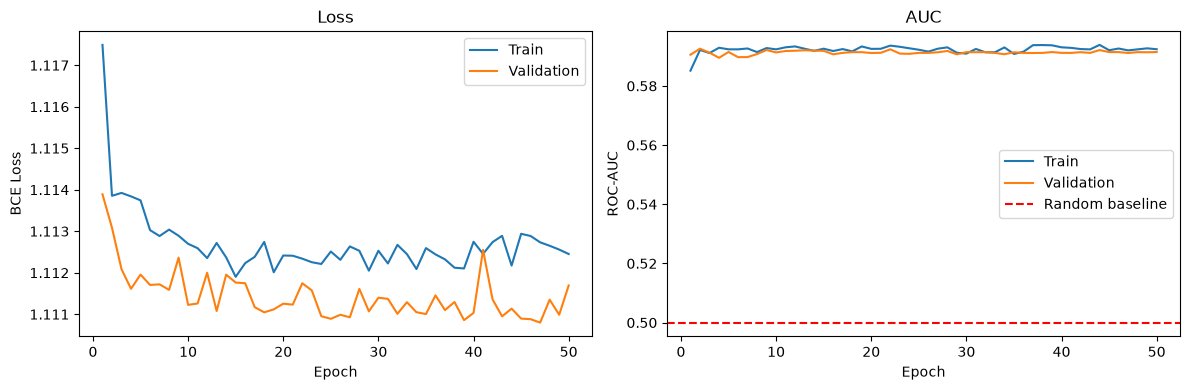

Training curves saved.


In [19]:
# Save best model state
model_path = config.OUTPUTS_DIR / "mlp_baseline.pt"
config.OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
torch.save(best_model_state, model_path)
print(f"Best model saved to {model_path}")

# Plot training curves
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, NUM_EPOCHS + 1)

ax1.plot(epochs, history['train_loss'], label='Train')
ax1.plot(epochs, history['val_loss'], label='Validation')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('BCE Loss')
ax1.legend()

ax2.plot(epochs, history['train_auc'], label='Train')
ax2.plot(epochs, history['val_auc'], label='Validation')
ax2.axhline(y=0.5, color='r', linestyle='--', label='Random baseline')
ax2.set_title('AUC')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('ROC-AUC')
ax2.legend()

plt.tight_layout()
fig.savefig(config.FIGURES_DIR / "mlp_baseline_training.png", dpi=150, bbox_inches='tight')
plt.show()
print("Training curves saved.")

In [20]:
# Reload the filtered dataset to access gene and chromosome columns
df = pd.read_csv(
    config.PROCESSED_DIR / "clinvar_filtered.tsv.gz",
    sep='\t',
    low_memory=False
)

# Filter to SNVs and drop anomalous rows — same as preprocessing
df_snv = df[df['Type'] == 'single nucleotide variant'].copy()
df_snv = df_snv[df_snv['ReferenceAlleleVCF'].str.len() == 1]
df_snv = df_snv[df_snv['AlternateAlleleVCF'].str.len() == 1]
df_snv = df_snv[df_snv['ReferenceAlleleVCF'] != 'na']
df_snv = df_snv[df_snv['AlternateAlleleVCF'] != 'na']
df_snv = df_snv.reset_index(drop=True)

print(f"Shape: {df_snv.shape}")
print(f"\nUnique chromosomes: {sorted(df_snv['Chromosome'].unique())}")
print(f"\nUnique genes: {df_snv['GeneSymbol'].nunique()}")
print(f"\nTop 30 genes by count:")
print(df_snv['GeneSymbol'].value_counts().head(30))

Shape: (341825, 44)

Unique chromosomes: ['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '3', '4', '5', '6', '7', '8', '9', 'MT', 'X', 'Y']

Unique genes: 10045

Top 30 genes by count:
GeneSymbol
TTN        5112
BRCA2      3873
ATM        3417
BRCA1      2693
NF1        2613
APC        2522
TSC2       2480
MSH6       1801
POLE       1696
FBN1       1691
RYR1       1577
RYR2       1514
MSH2       1508
MLH1       1277
SMARCA4    1236
DMD        1223
LDLR       1203
DICER1     1180
BRIP1      1133
PMS2       1132
PALB2      1127
CDH1       1110
POLD1      1070
CFTR       1056
FANCA      1049
PTCH1      1041
MYH7        978
ZNF469      969
TSC1        949
NOTCH1      935
Name: count, dtype: int64


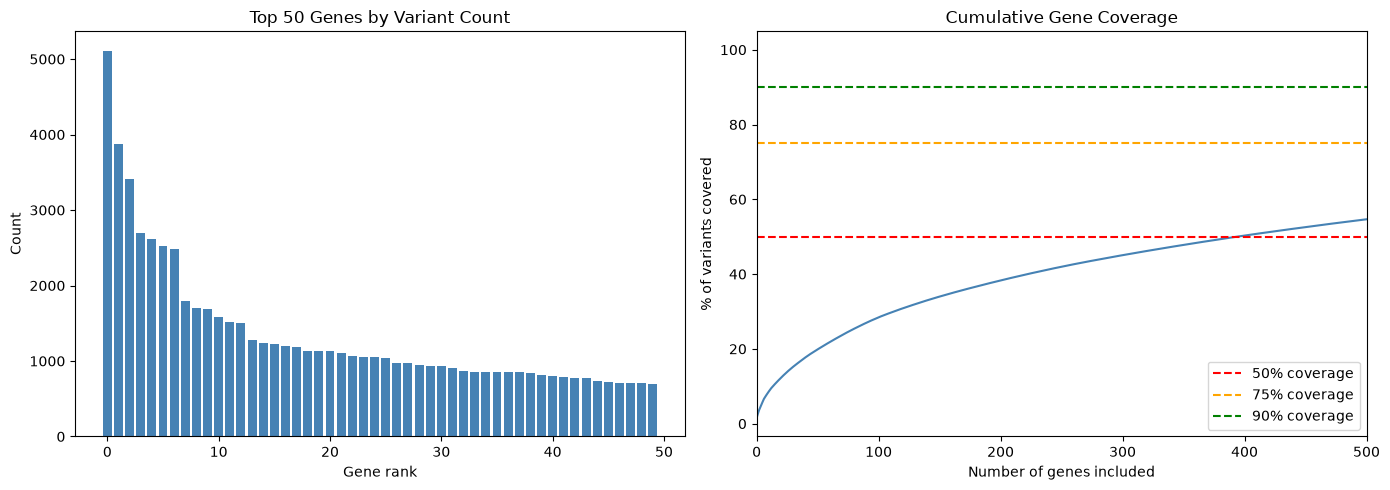

50% of variants covered by top 395 genes
75% of variants covered by top 1299 genes
90% of variants covered by top 2745 genes


In [21]:
import matplotlib.pyplot as plt

gene_counts = df_snv['GeneSymbol'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Top 50 genes
ax1.bar(range(50), gene_counts.values[:50], color='steelblue')
ax1.set_title('Top 50 Genes by Variant Count')
ax1.set_xlabel('Gene rank')
ax1.set_ylabel('Count')

# Cumulative coverage
cumulative = gene_counts.cumsum() / gene_counts.sum() * 100
ax2.plot(range(len(cumulative)), cumulative.values, color='steelblue')
ax2.axhline(y=50, color='r', linestyle='--', label='50% coverage')
ax2.axhline(y=75, color='orange', linestyle='--', label='75% coverage')
ax2.axhline(y=90, color='g', linestyle='--', label='90% coverage')
ax2.set_title('Cumulative Gene Coverage')
ax2.set_xlabel('Number of genes included')
ax2.set_ylabel('% of variants covered')
ax2.legend()
ax2.set_xlim(0, 500)

plt.tight_layout()
fig.savefig(config.FIGURES_DIR / "gene_coverage.png", dpi=150, bbox_inches='tight')
plt.show()

# Find cutoffs
for pct in [50, 75, 90]:
    n_genes = (cumulative < pct).sum() + 1
    print(f"{pct}% of variants covered by top {n_genes} genes")

In [22]:
# Top 50 genes + other bucket
TOP_N_GENES = 50
top_genes = df_snv['GeneSymbol'].value_counts().head(TOP_N_GENES).index.tolist()
gene_to_idx = {gene: i for i, gene in enumerate(top_genes)}
# Index TOP_N_GENES = "other"

# Chromosome encoding
CHROMOSOMES = ['1','2','3','4','5','6','7','8','9','10',
               '11','12','13','14','15','16','17','18','19','20',
               '21','22','X','Y','MT']
chrom_to_idx = {c: i for i, c in enumerate(CHROMOSOMES)}

def encode_enriched(ref, alt, gene, chrom):
    # Allele one-hot (8)
    allele = one_hot_encode(ref) + one_hot_encode(alt)
    
    # Gene one-hot (51: top 50 + other)
    gene_vec = [0] * (TOP_N_GENES + 1)
    gene_vec[gene_to_idx.get(gene, TOP_N_GENES)] = 1
    
    # Chromosome one-hot (25)
    chrom_vec = [0] * len(CHROMOSOMES)
    chrom_idx = chrom_to_idx.get(str(chrom), 0)
    chrom_vec[chrom_idx] = 1
    
    return allele + gene_vec + chrom_vec

# Need one_hot_encode from earlier
NUCLEOTIDES = ['A', 'C', 'G', 'T']
def one_hot_encode(base):
    vector = [0, 0, 0, 0]
    if base in NUCLEOTIDES:
        vector[NUCLEOTIDES.index(base)] = 1
    return vector

# Apply encoding
print("Encoding enriched features...")
X_enriched = np.array([
    encode_enriched(ref, alt, gene, chrom)
    for ref, alt, gene, chrom in zip(
        df_snv['ReferenceAlleleVCF'],
        df_snv['AlternateAlleleVCF'],
        df_snv['GeneSymbol'],
        df_snv['Chromosome']
    )
])
y_enriched = df_snv['Label'].values

print(f"X_enriched shape: {X_enriched.shape}")
print(f"Feature breakdown: 8 allele + 51 gene + 25 chrom = {8+51+25} total")
print(f"\nExample enriched vector length: {len(X_enriched[0])}")

Encoding enriched features...
X_enriched shape: (341825, 84)
Feature breakdown: 8 allele + 51 gene + 25 chrom = 84 total

Example enriched vector length: 84


In [24]:
from sklearn.model_selection import train_test_split

# Stratified split — same proportions as before
X_tr, X_te, y_tr, y_te = train_test_split(
    X_enriched, y_enriched,
    test_size=config.TEST_SIZE,
    random_state=config.RANDOM_SEED,
    stratify=y_enriched
)

X_tr, X_va, y_tr, y_va = train_test_split(
    X_tr, y_tr,
    test_size=config.VAL_SIZE / (1 - config.TEST_SIZE),
    random_state=config.RANDOM_SEED,
    stratify=y_tr
)

print(f"Train:      {X_tr.shape} | Labels: {np.bincount(y_tr)}")
print(f"Validation: {X_va.shape} | Labels: {np.bincount(y_va)}")
print(f"Test:       {X_te.shape} | Labels: {np.bincount(y_te)}")

# DataLoaders
train_ds = VariantDataset(X_tr, y_tr)
val_ds   = VariantDataset(X_va, y_va)
test_ds  = VariantDataset(X_te, y_te)

train_ld = DataLoader(train_ds, batch_size=config.BATCH_SIZE, shuffle=True)
val_ld   = DataLoader(val_ds,   batch_size=config.BATCH_SIZE, shuffle=False)
test_ld  = DataLoader(test_ds,  batch_size=config.BATCH_SIZE, shuffle=False)

print("\nDataLoaders ready.")

Train:      (239277, 84) | Labels: [196606  42671]
Validation: (34183, 84) | Labels: [28087  6096]
Test:       (68365, 84) | Labels: [56173 12192]

DataLoaders ready.


In [26]:
class EnrichedMLP(nn.Module):
    """
    MLP with enriched features for ClinVar SNV classification.
    
    Input: 84-dimensional vector
        - 8:  one-hot allele (ref + alt)
        - 51: one-hot gene (top 50 + other)
        - 25: one-hot chromosome
    Output: single logit for binary classification

    Wider than baseline MLP to handle richer input.
    Establishes whether gene/chromosome context improves over allele-only.
    Expected to reveal gene-level ascertainment bias as confounder.
    """
    def __init__(self, input_dim=84, hidden_dims=[256, 128, 64], dropout=0.3):
        super(EnrichedMLP, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dims[0]),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dims[0], hidden_dims[1]),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dims[1], hidden_dims[2]),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dims[2], 1)
        )

    def forward(self, x):
        return self.network(x).squeeze(1)


# Class weight
n_benign     = np.bincount(y_tr)[0]
n_pathogenic = np.bincount(y_tr)[1]
pos_weight   = torch.tensor([n_benign / n_pathogenic], dtype=torch.float32).to(config.DEVICE)

# Instantiate
enriched_model = EnrichedMLP().to(config.DEVICE)
criterion      = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimiser      = torch.optim.Adam(enriched_model.parameters(), lr=config.LEARNING_RATE)

print(enriched_model)
print(f"\nTotal parameters: {sum(p.numel() for p in enriched_model.parameters()):,}")
print(f"Model device: {next(enriched_model.parameters()).device}")

EnrichedMLP(
  (network): Sequential(
    (0): Linear(in_features=84, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=64, out_features=1, bias=True)
  )
)

Total parameters: 62,977
Model device: cuda:0


In [27]:
NUM_EPOCHS = config.MAX_EPOCHS
best_val_auc = 0.0
best_model_state = None
history_enriched = {'train_loss': [], 'train_auc': [], 'val_loss': [], 'val_auc': []}

print(f"Training EnrichedMLP for {NUM_EPOCHS} epochs on {config.DEVICE}")
print(f"{'Epoch':>6} {'Train Loss':>12} {'Train AUC':>12} {'Val Loss':>10} {'Val AUC':>10}")
print("-" * 56)

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_auc = train_epoch(
        enriched_model, train_ld, criterion, optimiser, config.DEVICE
    )
    val_loss, val_auc = evaluate(
        enriched_model, val_ld, criterion, config.DEVICE
    )

    history_enriched['train_loss'].append(train_loss)
    history_enriched['train_auc'].append(train_auc)
    history_enriched['val_loss'].append(val_loss)
    history_enriched['val_auc'].append(val_auc)

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_model_state = enriched_model.state_dict().copy()

    print(f"{epoch:>6} {train_loss:>12.4f} {train_auc:>12.4f} {val_loss:>10.4f} {val_auc:>10.4f}")

print("-" * 56)
print(f"Best validation AUC: {best_val_auc:.4f}")

Training EnrichedMLP for 50 epochs on cuda
 Epoch   Train Loss    Train AUC   Val Loss    Val AUC
--------------------------------------------------------
     1       1.0652       0.6556     1.0510     0.6701
     2       1.0556       0.6654     1.0526     0.6699
     3       1.0540       0.6673     1.0484     0.6698
     4       1.0531       0.6677     1.0499     0.6698
     5       1.0529       0.6688     1.0485     0.6709
     6       1.0528       0.6685     1.0487     0.6715
     7       1.0527       0.6692     1.0505     0.6708
     8       1.0521       0.6695     1.0537     0.6714
     9       1.0524       0.6691     1.0499     0.6706
    10       1.0520       0.6695     1.0502     0.6706
    11       1.0521       0.6697     1.0500     0.6718
    12       1.0524       0.6695     1.0506     0.6709
    13       1.0516       0.6700     1.0531     0.6710
    14       1.0517       0.6703     1.0504     0.6706
    15       1.0527       0.6691     1.0499     0.6708
    16       1.0515 

In [28]:
# Evaluate enriched model on test set
enriched_model.load_state_dict(best_model_state)
enriched_model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_ld:
        X_batch = X_batch.to(config.DEVICE)
        logits = enriched_model(X_batch)
        probs = torch.sigmoid(logits).cpu().numpy()
        all_preds.extend(probs)
        all_labels.extend(y_batch.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# Get gene labels for test set
test_genes = df_snv['GeneSymbol'].values
_, X_te_idx, _, _ = train_test_split(
    np.arange(len(y_enriched)), y_enriched,
    test_size=config.TEST_SIZE,
    random_state=config.RANDOM_SEED,
    stratify=y_enriched
)
test_gene_labels = test_genes[X_te_idx]

# Split by top-50 vs other
top50_mask = np.array([g in top_genes for g in test_gene_labels])
other_mask  = ~top50_mask

auc_top50 = roc_auc_score(all_labels[top50_mask], all_preds[top50_mask])
auc_other  = roc_auc_score(all_labels[other_mask], all_preds[other_mask])
auc_overall = roc_auc_score(all_labels, all_preds)

print(f"Overall AUC:        {auc_overall:.4f}")
print(f"Top-50 gene AUC:    {auc_top50:.4f}  ({top50_mask.sum():,} variants)")
print(f"'Other' gene AUC:   {auc_other:.4f}  ({other_mask.sum():,} variants)")
print(f"\nAUC gap: {auc_top50 - auc_other:.4f}")

Overall AUC:        0.6693
Top-50 gene AUC:    0.8285  (13,451 variants)
'Other' gene AUC:   0.6127  (54,914 variants)

AUC gap: 0.2158


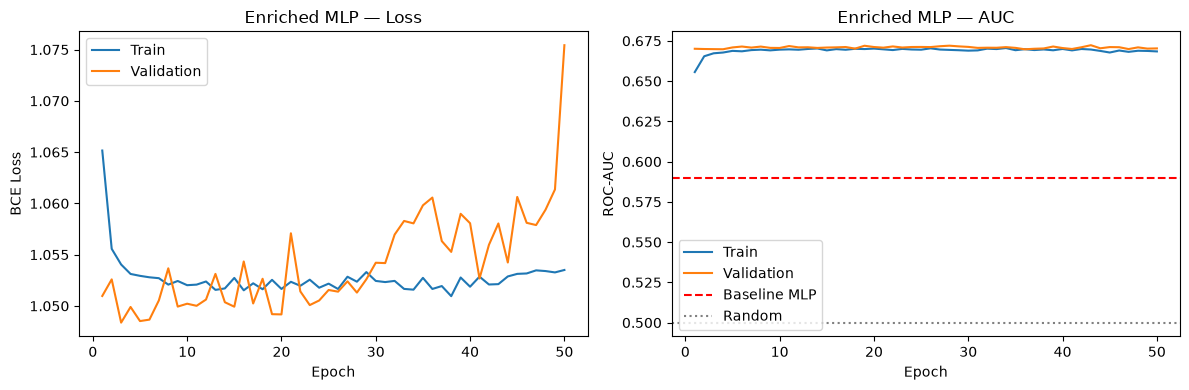

Saved.


In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, NUM_EPOCHS + 1)

ax1.plot(epochs, history_enriched['train_loss'], label='Train')
ax1.plot(epochs, history_enriched['val_loss'], label='Validation')
ax1.set_title('Enriched MLP — Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('BCE Loss')
ax1.legend()

ax2.plot(epochs, history_enriched['train_auc'], label='Train')
ax2.plot(epochs, history_enriched['val_auc'], label='Validation')
ax2.axhline(y=0.59, color='r', linestyle='--', label='Baseline MLP')
ax2.axhline(y=0.5, color='gray', linestyle=':', label='Random')
ax2.set_title('Enriched MLP — AUC')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('ROC-AUC')
ax2.legend()

plt.tight_layout()
fig.savefig(config.FIGURES_DIR / "mlp_enriched_training.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [30]:
# Reload baseline model
baseline_model = VariantMLP().to(config.DEVICE)
baseline_model.load_state_dict(torch.load(config.OUTPUTS_DIR / "mlp_baseline.pt"))
baseline_model.eval()

# Load original splits
X_test_base = np.load(config.PROCESSED_DIR / "X_test.npy")
y_test_base = np.load(config.PROCESSED_DIR / "y_test.npy")

base_dataset = VariantDataset(X_test_base, y_test_base)
base_loader = DataLoader(base_dataset, batch_size=config.BATCH_SIZE, shuffle=False)

all_preds_base, all_labels_base = [], []
with torch.no_grad():
    for X_batch, y_batch in base_loader:
        X_batch = X_batch.to(config.DEVICE)
        logits = baseline_model(X_batch)
        probs = torch.sigmoid(logits).cpu().numpy()
        all_preds_base.extend(probs)
        all_labels_base.extend(y_batch.numpy())

all_preds_base = np.array(all_preds_base)
all_labels_base = np.array(all_labels_base)

# Get test gene labels using same split
_, X_te_idx_base, _, _ = train_test_split(
    np.arange(len(y_enriched)), y_enriched,
    test_size=config.TEST_SIZE,
    random_state=config.RANDOM_SEED,
    stratify=y_enriched
)
test_gene_labels_base = test_genes[X_te_idx_base]

top50_mask_base = np.array([g in top_genes for g in test_gene_labels_base])
other_mask_base = ~top50_mask_base

auc_top50_base = roc_auc_score(all_labels_base[top50_mask_base], all_preds_base[top50_mask_base])
auc_other_base = roc_auc_score(all_labels_base[other_mask_base], all_preds_base[other_mask_base])
auc_overall_base = roc_auc_score(all_labels_base, all_preds_base)

print("Baseline MLP per-group AUC:")
print(f"Overall AUC:        {auc_overall_base:.4f}")
print(f"Top-50 gene AUC:    {auc_top50_base:.4f}  ({top50_mask_base.sum():,} variants)")
print(f"'Other' gene AUC:   {auc_other_base:.4f}  ({other_mask_base.sum():,} variants)")
print(f"AUC gap:            {auc_top50_base - auc_other_base:.4f}")

Baseline MLP per-group AUC:
Overall AUC:        0.5947
Top-50 gene AUC:    0.6554  (13,451 variants)
'Other' gene AUC:   0.5774  (54,914 variants)
AUC gap:            0.0779
